In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1: density peaks

In [2]:
# auxiliary functions for density peaks
def distance_matrix(data):
    fact_1 = np.tile(data.reshape((data.shape[0], 1, data.shape[1])), (1, data.shape[0], 1))
    fact_2 = np.tile(data.reshape((1, data.shape[0], data.shape[1])), (data.shape[0], 1, 1))
    return np.linalg.norm(fact_1-fact_2, axis=-1)

def density_vector(dist_mat, dc):
    return np.sum(np.exp(- np.square(dist_mat/dc)), axis=1)

def hdn_idxs_dist(dist_mat, dens_vec):
    hdn_dist = np.zeros_like(dens_vec)
    hdn_idxs = np.zeros_like(dens_vec, dtype='int')
    mxrho = np.argmax(dens_vec)
    mxdist = np.max(dist_mat)
    for i in range(dist_mat.shape[0]):
        if i==mxrho:
            hdn_idxs[i] = np.argmax(dist_mat[i])
            hdn_dist[i] = dist_mat[i,hdn_idxs[i]]
            continue
        hdn_idxs[i] = np.argmin(dist_mat[i] + (dens_vec <= dens_vec[i])*mxdist)
        hdn_dist[i] = dist_mat[i,hdn_idxs[i]]
    return hdn_idxs, hdn_dist

def assign_to_cluster_nn(data, hdnn, centroid_idx):
    assigns = np.tile(np.array([-1,]), (data.shape[0])) # init assigns
    for c in range(centroid_idx.shape[0]):
        assigns[centroid_idx[c]] = c                    # fill centroids
    for i in range(data.shape[0]):
        if assigns[i] != -1:                            # if already assigned skip
            continue
        neigh = hdnn[i]                                    
        tba = [i,]
        while(assigns[neigh]) == -1:                    # loop up to the first neighbor filled
            tba.append(neigh)
            neigh = hdnn[neigh]
        cluster_idx = assigns[neigh]
        for tba_neigh in tba:                           # fill all the ones up to the one found
            assigns[tba_neigh] = cluster_idx      
    return assigns

In [3]:
# density peaks
def density_peaks_plot(data, dc):
    dm = distance_matrix(data)
    dv = density_vector(dm, dc)
    _, rv = hdn_idxs_dist(dm, dv)
    plt.title("density peaks")
    plt.xlabel(r"$\rho$")
    plt.ylabel(r"$\delta$")
    plt.scatter(dv, rv)
    plt.show()
    
def density_peaks_clustering(data, dc, n_clusters):
    dm = distance_matrix(data)
    dv = density_vector(dm, dc)
    hdn_idxs, rv = hdn_idxs_dist(dm, dv)
    sorted_gamma_idx = np.argsort(np.multiply(dv,rv))[::-1] # get idx of biggest values of gamma_i=delta_i*rho_i
    centroids = data[sorted_gamma_idx[:n_clusters]]         # get number of centroids
    return centroids, assign_to_cluster_nn(data, hdn_idxs, sorted_gamma_idx[:n_clusters])

def plot_clusters(data, assigns, centroids):
    for i in range(centroids.shape[0]):
        cluster = data[assigns==i]
        plt.scatter(cluster[:,0], cluster[:,1], s=4)
    plt.scatter(centroids[:,0], centroids[:,1], s=12, c='k')
    

#### Application to aggregation dataset

In [4]:
dataset_agg = np.loadtxt("data/Aggregation.txt") # load labeled data
ground_agg = dataset_agg[:,2]                    # separate labels from data -> labels
data_agg = dataset_agg[:,:2]                     # separate labels from data -> data

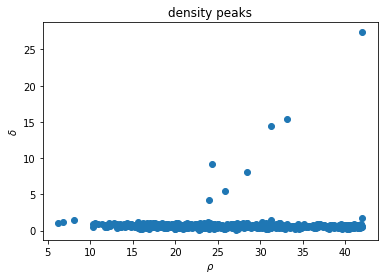

CPU times: user 1.31 s, sys: 52.8 ms, total: 1.37 s
Wall time: 297 ms


In [5]:
%time density_peaks_plot(data_agg, 2.5) # find density peaks

CPU times: user 179 ms, sys: 10.5 ms, total: 189 ms
Wall time: 34.5 ms


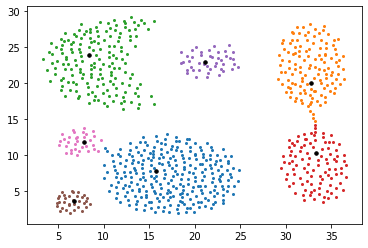

In [6]:
# choose clusters number based on plot -> 7 clusters
%time centroids_agg, assigns_agg = density_peaks_clustering(data_agg, 2.5, 7)
plot_clusters(data_agg, assigns_agg, centroids_agg)

#### Application to s3 dataset

In [7]:
data_s3 = np.loadtxt("data/s3.txt")         # load unlabeled data
ground_s3 = np.loadtxt("data/s3ground.txt") # load ground truth data

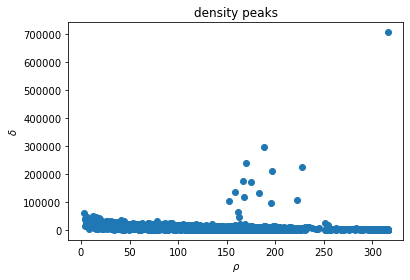

CPU times: user 4.45 s, sys: 989 ms, total: 5.44 s
Wall time: 1.45 s


In [8]:
%time density_peaks_plot(data_s3, 57500) # plot density peaks

CPU times: user 4.2 s, sys: 979 ms, total: 5.18 s
Wall time: 1.3 s


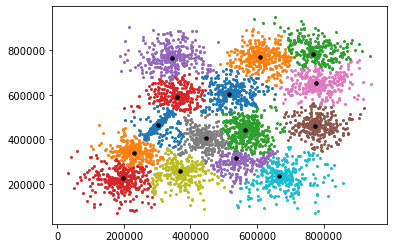

In [9]:
# choose clusters number based on plot -> 15 clusters
%time centroids_s3, assigns_s3 = density_peaks_clustering(data_s3, 57500, 15)
plot_clusters(data_s3, assigns_s3, centroids_s3)

## Exercise 2: cluster validation

In [10]:
# functions for k-means
def update_assigns(data, centroids):
    return np.argmin(np.linalg.norm(np.tile(centroids, \
            (data.shape[0],1,1)) - data.reshape((data.shape[0],1,data.shape[1])), axis=2),axis=1).astype('int32')

def update_centroids(data, assigns, centroids):
    new_centroids = np.ndarray(shape=(centroids.shape[0], data.shape[1]), dtype='float64')
    for i in range(centroids.shape[0]):
        block = data[assigns==i]
        new_centroids[i] = np.mean(block, axis=0) if block.shape[0]!=0 else centroids[i]
    return new_centroids

def compute_loss(data, assigns, centroids):
    get_centroid = lambda n: centroids[n]
    return np.sum(np.square(data-get_centroid(assigns)))
  
def _kmeans(data, n_clusters):
    centroids = data[np.random.randint(0, data.shape[0], (n_clusters,))]                      # random centroids
    assigns = np.zeros(shape=(data.shape[0],))                                                # init assigns vector
    changed = True; rep=0
    while(changed and rep < 100): 
        new_assigns = update_assigns(data, centroids)                                         # get updated assigns
        changed = True if (new_assigns != assigns).any() else False                           # check if changed
        centroids = update_centroids(data, new_assigns, centroids) if changed else centroids  # update centroids
        assigns = new_assigns if changed else assigns                                         # update assigns 
        rep += 1
    loss = compute_loss(data, assigns, centroids)                                             # compute loss
    return centroids, assigns, loss

# function to run multiple jobs in parallel and return best
def kmeans(data, n_clusters=15, reps=10):  
    _results = []
    for i in range(reps):
        _results.append(_kmeans(data, n_clusters))
    _losses = [_results[i][2] for i in range(reps)]
    _avg = np.mean(_losses); 
    _best = _results[np.argmin(_losses)]
    return _best[0], _best[1], _best[2], _avg

#### Perform k-means on both datasets

CPU times: user 451 ms, sys: 5.13 ms, total: 456 ms
Wall time: 454 ms


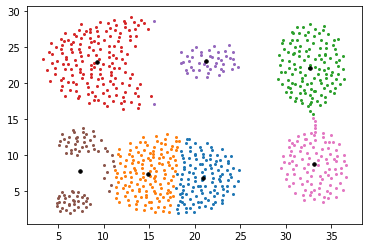

In [11]:
# k-means for aggregation dataset
%time centroids_km_agg, assigns_km_agg, *_ = kmeans(data_agg, n_clusters=7, reps=100)
plot_clusters(data_agg, assigns_km_agg, centroids_km_agg)

CPU times: user 26.5 s, sys: 108 ms, total: 26.7 s
Wall time: 5.34 s


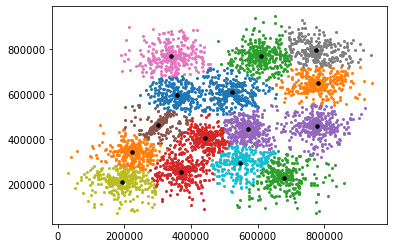

In [12]:
# k-means for s3 dataset
%time centroids_km_s3, assigns_km_s3, *_ = kmeans(data_s3, n_clusters=15, reps=100)
plot_clusters(data_s3, assigns_km_s3, centroids_km_s3)

#### Comparing F-ratios

In [13]:
# functions to compute F-ratio
def ssw(data, assigns, centroids):
    return np.sum(np.square(data - centroids[assigns]))

def ssb(data, assigns, centroids):
    ssb_var = 0.0
    mean_x = np.mean(data, axis=0)
    for i in range(centroids.shape[0]):
        ssb_var += np.sum(assigns==i) * np.sum(np.square(centroids[i] - mean_x))
    return ssb_var

def f_ratio(data, assigns, centroids):
    return centroids.shape[0] * ssw(data, assigns, centroids) / ssb(data, assigns, centroids)

In [14]:
# compare F-ratios for aggregation dataset
print(f"F-ratio dpeaks: {f_ratio(data_agg, assigns_agg, centroids_agg)}")
print(f"F-ratio kmeans: {f_ratio(data_agg, assigns_km_agg, centroids_km_agg)}")

F-ratio dpeaks: 0.8639409727670921
F-ratio kmeans: 0.6524350953324933


In [15]:
# compare F-ratios for s3 dataset
print(f"F-ratio dpeaks: {f_ratio(data_s3, assigns_s3, centroids_s3)}")
print(f"F-ratio kmeans: {f_ratio(data_s3, assigns_km_s3, centroids_km_s3)}")

F-ratio dpeaks: 0.7640503274998506
F-ratio kmeans: 0.6769795600695822


#### Comparing normalized mutual information

In [16]:
# functions to compute normalized mutual information
def normalized_mutual_info(computed, ground):
    assert computed.shape[0] == ground.shape[0]
    # get assigns probs
    computed_vals, computed_counts = np.unique(computed, return_counts=True)
    computed_probs = computed_counts / computed.shape[0]
    computed_entropy = - np.sum(np.multiply(computed_probs, np.log(computed_probs)))
    # get ground truth probs
    ground_vals, ground_counts = np.unique(ground, return_counts=True)
    ground_probs = ground_counts / ground.shape[0]
    ground_entropy = - np.sum(np.multiply(ground_probs, np.log(ground_probs)))
    # get conditional probs
    mixed_counts = np.zeros(shape=(ground_vals.shape[0], computed_vals.shape[0]), dtype='int')
    for i in range(ground_vals.shape[0]):
        mask = (ground==ground_vals[i])
        for j in range(computed_vals.shape[0]):
            mixed_counts[i][j] += np.sum(computed[mask]==computed_vals[j]) 
    mixed_probs = mixed_counts / computed.shape[0]
    # compute mutual information
    mutual_info = 0.0
    for i in range(ground_vals.shape[0]):
        for j in range(computed_vals.shape[0]):
            if mixed_probs[i,j] != 0:
                mutual_info += mixed_probs[i,j] * np.log(mixed_probs[i,j]/ \
                                                  (computed_probs[j]*ground_probs[i]))
    # return normalized mutual info
    return 2*mutual_info/(ground_entropy+computed_entropy)

In [17]:
# check that function is working correctly
from sklearn.metrics import normalized_mutual_info_score
print(f"Manual : {normalized_mutual_info(assigns_km_agg, ground_agg)}")
print(f"sklearn: {normalized_mutual_info_score(ground_agg, assigns_km_agg)}")

Manual : 0.8792390052708805
sklearn: 0.8792390052708804


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [18]:
# compare normalized mutual infos for aggregation dataset
print(f"NMI score dpeaks: {normalized_mutual_info(assigns_agg, ground_agg)}")
print(f"NMI score kmeans: {normalized_mutual_info(assigns_km_agg, ground_agg)}")

NMI score dpeaks: 1.0000000000000002
NMI score kmeans: 0.8792390052708805


In [19]:
# compare normalized mutual infos for s3 dataset
print(f"NMI score dpeaks: {normalized_mutual_info(assigns_s3, ground_s3)}")
print(f"NMI score kmeans: {normalized_mutual_info(assigns_km_s3, ground_s3)}")

NMI score dpeaks: 0.785441614983089
NMI score kmeans: 0.7944445251407665
